# Inpainting Test Notebook (MSPS)

Use JSON config to run one inpainting test with `MSPS`.

In [1]:
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from inpaintingStart import get_operator
from pixelflow.pipeline_MSposteriorSampling import MSPS3
from pixelflow.scheduling_pixelflow import PixelFlowScheduler
from pixelflow.utils import config as config_utils
from pixelflow.utils.misc import seed_everything

/home/ruy45/anaconda3/envs/pixelflow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CONFIG_PATH = Path('./test_inpainting_config.json')
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = json.load(f)

print('Loaded config from:', CONFIG_PATH.resolve())
print('experiment_name:', cfg.get('experiment_name'))

Loaded config from: /home/ruy45/MSFlow/PixelFlow/test_inpainting_config.json
experiment_name: inpainting_grid


In [3]:
def center_crop_arr(pil_image, image_size):
    while min(*pil_image.size) >= 2 * image_size:
        pil_image = pil_image.resize(tuple(x // 2 for x in pil_image.size), resample=Image.BOX)

    scale = image_size / min(*pil_image.size)
    pil_image = pil_image.resize(tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC)

    arr = np.array(pil_image)
    crop_y = (arr.shape[0] - image_size) // 2
    crop_x = (arr.shape[1] - image_size) // 2
    return Image.fromarray(arr[crop_y: crop_y + image_size, crop_x: crop_x + image_size])

def pick_grid_value(v):
    if isinstance(v, list) and len(v) > 0:
        return v[0]
    return v

def normalize_stage_steps(steps, num_stages):
    if isinstance(steps, int):
        return [int(steps)] * num_stages
    if isinstance(steps, list):
        out = [int(x) for x in steps]
        if len(out) != num_stages:
            raise ValueError(f'steps list length must equal num_stages={num_stages}, got {len(out)}')
        return out
    raise TypeError(f'Unsupported steps type: {type(steps)}')

resolution = int(cfg['resolution'])
num_stages = int(cfg['num_stages'])
num_examples = int(cfg['num_examples'])
raw_class_label = cfg['class_label']
class_label = None if raw_class_label is None else int(raw_class_label)
guidance = float(cfg['guidance'])
shift = float(cfg['shift'])
device = torch.device(cfg['device'])

seed_everything(int(cfg['seed']))

data_dir = os.path.expanduser(cfg['data_dir'])
transform = transforms.Compose([
    transforms.Lambda(lambda pil_image: center_crop_arr(pil_image, resolution)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True),
])
dataset = ImageFolder(data_dir, transform=transform)

if class_label is None or class_label == 1000:
    idx = torch.randperm(len(dataset))[:num_examples]
else:
    candidate_indices = [i for i, y_label in enumerate(dataset.targets) if int(y_label) == class_label]
    if len(candidate_indices) < num_examples:
        raise ValueError(f'class_label={class_label} has only {len(candidate_indices)} samples; num_examples={num_examples}')
    chosen = torch.randperm(len(candidate_indices))[:num_examples].tolist()
    idx = torch.tensor([candidate_indices[i] for i in chosen], dtype=torch.long)

gt = torch.stack([dataset[i][0] for i in idx], dim=0).to(device)
print('gt shape:', tuple(gt.shape), '| device:', gt.device, '| class_label:', class_label)

gt shape: (4, 3, 256, 256) | device: cuda:1 | class_label: 10


In [4]:
sigma_n = float(cfg['sigma_n'])
operator_name = cfg['operator_name']
operator_mask_type = cfg['operator_mask_type']
operator_mask_len_range = tuple(int(v) for v in cfg['operator_mask_len_range'])
operator_mask_prob_range = cfg.get('operator_mask_prob_range', None)

A_opr = get_operator(
    operator_name,
    mask_type=operator_mask_type,
    mask_len_range=operator_mask_len_range,
    mask_prob_range=operator_mask_prob_range,
    resolution=resolution,
    device=device,
    sigma=sigma_n,
)

y = A_opr.measure(gt).to(device)
print('y shape:', tuple(y.shape))

y shape: (4, 3, 256, 256)


In [5]:
yd = A_opr.measure(gt, 8).to(device)
yd.shape

torch.Size([4, 3, 32, 32])

(np.float64(-0.5), np.float64(1033.5), np.float64(259.5), np.float64(-0.5))

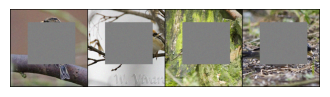

In [6]:
y_vis = (y.cpu() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")


(np.float64(-0.5), np.float64(137.5), np.float64(35.5), np.float64(-0.5))

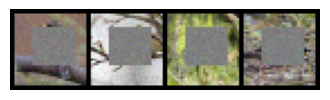

In [7]:
y_vis = (yd.cpu() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")


In [8]:
model_dir = os.path.expanduser(cfg['model_dir'])
config = OmegaConf.load(f'{model_dir}/config.yaml')
model = config_utils.instantiate_from_config(config.model).to(device)
ckpt = torch.load(f'{model_dir}/model.pt', map_location='cpu', weights_only=False)
model.load_state_dict(ckpt, strict=True)
model.eval()

scheduler = PixelFlowScheduler(
    config.scheduler.num_train_timesteps,
    num_stages=config.scheduler.num_stages,
    gamma=float(cfg['scheduler_gamma']),
)

langevin_proj = bool(pick_grid_value(cfg['langevin_proj']))
langevin_num_steps = int(pick_grid_value(cfg['num_langevin_steps']))
langevin_step_base = float(pick_grid_value(cfg['lr_base']))
langevin_step_min_ratio = float(pick_grid_value(cfg['lr_min_ratio']))

sampler = MSPS3(
    y=y,
    operator=A_opr,
    scheduler=scheduler,
    transformer=model,
    text_encoder=None,
    tokenizer=None,
    max_token_length=cfg["max_token_length"],
    langevin_num_steps=...,
    langevin_step_base=...,
    langevin_step_min_ratio=...,
    sigma_n=...,
    langevin_proj=...,
    ds_type="bilinear",
)

num_inference_steps = normalize_stage_steps(pick_grid_value(cfg['num_inference_steps']), scheduler.num_stages)
prompt_label = 1000 if class_label is None else class_label
prompts = [prompt_label] * num_examples

print('num_inference_steps:', num_inference_steps)
print('langevin_proj:', langevin_proj, '| langevin_num_steps:', langevin_num_steps)

Starting Initialization...
num_inference_steps: [10, 10, 10, 10]
langevin_proj: False | langevin_num_steps: 50


/home/ruy45/MSFlow/PixelFlow/pixelflow/pipeline_MSposteriorSampling.py:45: UserWarning: langevin_step_base is Ellipsis; fallback to default 0.0001.
  warnings.warn(
/home/ruy45/MSFlow/PixelFlow/pixelflow/pipeline_MSposteriorSampling.py:45: UserWarning: langevin_step_min_ratio is Ellipsis; fallback to default 0.01.
  warnings.warn(
/home/ruy45/MSFlow/PixelFlow/pixelflow/pipeline_MSposteriorSampling.py:45: UserWarning: langevin_num_steps is Ellipsis; fallback to default 30.
  warnings.warn(
/home/ruy45/MSFlow/PixelFlow/pixelflow/pipeline_MSposteriorSampling.py:45: UserWarning: sigma_n is Ellipsis; fallback to default 0.05.
  warnings.warn(


In [9]:
if device.type == 'cuda':
    torch.cuda.synchronize(device)
t0 = time.perf_counter()

with torch.no_grad(), torch.autocast('cuda', dtype=torch.bfloat16):
    samples, x0_before, x0_after, pixel_end_traj = sampler(
        prompt=prompts,
        height=resolution,
        width=resolution,
        num_inference_steps=num_inference_steps,
        guidance_scale=0.0,
        num_images_per_prompt=1,
        device=device,
        shift=1.0,
        use_ode_dopri5=False,   # MSPS2 目前只支持 False
        return_t0_traj=True,
        return_pixel_end_traj=True,
        save_pixel_end_images=True,
        save_pixel_end_dir="./outputs/msps3_pixel_end",
        stage_start=0,
        return_langevin_traj=True
    )



if device.type == 'cuda':
    torch.cuda.synchronize(device)
dt = time.perf_counter() - t0
print(f'samples shape: {samples.shape}, time: {dt:.2f}s')

{'loss': 1.166242003440857, 'z_mean': -0.0753270760178566, 'z_std': 0.07787847518920898}
{'loss': 1.1661441326141357, 'z_mean': -0.07540007680654526, 'z_std': 0.08995205163955688}
{'loss': 1.1662009954452515, 'z_mean': -0.0755310207605362, 'z_std': 0.1010703444480896}
{'loss': 0.9804301261901855, 'z_mean': -0.1359890252351761, 'z_std': 0.11296751350164413}
{'loss': 0.9806942939758301, 'z_mean': -0.13608144223690033, 'z_std': 0.12172988802194595}
{'loss': 0.9807925224304199, 'z_mean': -0.13614621758460999, 'z_std': 0.1294122040271759}
{'loss': 0.692371666431427, 'z_mean': -0.27387070655822754, 'z_std': 0.1801811307668686}
{'loss': 0.6924294233322144, 'z_mean': -0.27435868978500366, 'z_std': 0.18481315672397614}
{'loss': 0.6927661895751953, 'z_mean': -0.27447038888931274, 'z_std': 0.19002360105514526}
{'loss': 0.4335198402404785, 'z_mean': -0.58503258228302, 'z_std': 0.2907482385635376}
{'loss': 0.4336985945701599, 'z_mean': -0.5840727686882019, 'z_std': 0.2937181890010834}
{'loss': 0.43

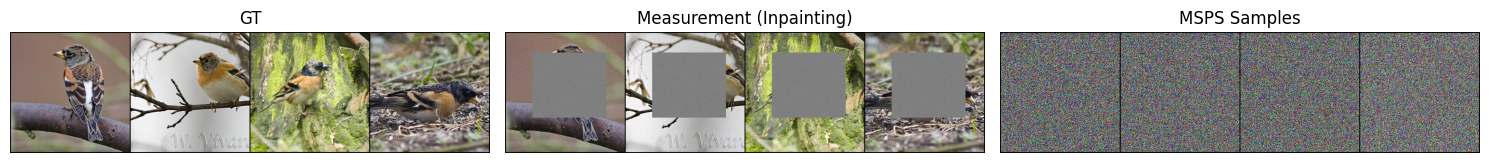

In [10]:
def to_disp_from_minus1_1(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

gt_vis = to_disp_from_minus1_1(gt.detach().cpu())
y_vis = to_disp_from_minus1_1(y.detach().cpu())
samples_vis = torch.from_numpy(samples).permute(0, 3, 1, 2).float().clamp(0, 1)

nrow = min(4, num_examples)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_grid(gt_vis, nrow=nrow).permute(1, 2, 0))
axes[0].set_title('GT')
axes[1].imshow(make_grid(y_vis, nrow=nrow).permute(1, 2, 0))
axes[1].set_title('Measurement (Inpainting)')
axes[2].imshow(make_grid(samples_vis, nrow=nrow).permute(1, 2, 0))
axes[2].set_title('MSPS Samples')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
save_root = Path(os.path.expanduser(cfg['output_root_dir'])) / 'notebook_test'
save_root.mkdir(parents=True, exist_ok=True)
ts = time.strftime('%Y%m%d_%H%M%S')
out_np = save_root / f'msps_samples_{ts}.npy'
np.save(out_np, samples)
print('Saved samples to:', out_np.resolve())

Saved samples to: /home/ruy45/MSFlow/PixelFlow/vis/IP/notebook_test/msps_samples_20260310_135443.npy


In [12]:
for i in range(4):
    stage_T_start = scheduler.Timesteps_per_stage[i][0].item()
    stage_T_end = scheduler.Timesteps_per_stage[i][-1].item()
    t_start = scheduler.t_window_per_stage[i][0].item()
    t_end = scheduler.t_window_per_stage[i][-1].item()
    print(stage_T_start, stage_T_end, t_start, t_end, scheduler.start_t[i],scheduler.end_t[i], )

0.0 174.825 0.0 0.999 0.0 0.25
175.0 425.749 0.0 0.999 0.14285714285714285 0.5
426.0 718.707 0.0 0.999 0.3333333333333333 0.75
719.0 999.0 0.0 0.999 0.6000000000000001 1.0


In [13]:
scheduler.t_window_per_stage[0]

tensor([0.0000, 0.0010, 0.0020, 0.0030, 0.0040, 0.0050, 0.0060, 0.0070, 0.0080,
        0.0090, 0.0100, 0.0110, 0.0120, 0.0130, 0.0140, 0.0150, 0.0160, 0.0170,
        0.0180, 0.0190, 0.0200, 0.0210, 0.0220, 0.0230, 0.0240, 0.0250, 0.0260,
        0.0270, 0.0280, 0.0290, 0.0300, 0.0310, 0.0320, 0.0330, 0.0340, 0.0350,
        0.0360, 0.0370, 0.0380, 0.0390, 0.0400, 0.0410, 0.0420, 0.0430, 0.0440,
        0.0450, 0.0460, 0.0470, 0.0480, 0.0490, 0.0500, 0.0510, 0.0520, 0.0530,
        0.0540, 0.0550, 0.0560, 0.0570, 0.0580, 0.0590, 0.0600, 0.0610, 0.0620,
        0.0630, 0.0640, 0.0650, 0.0660, 0.0670, 0.0680, 0.0690, 0.0700, 0.0710,
        0.0720, 0.0730, 0.0740, 0.0750, 0.0760, 0.0770, 0.0780, 0.0790, 0.0800,
        0.0810, 0.0820, 0.0830, 0.0840, 0.0850, 0.0860, 0.0870, 0.0880, 0.0890,
        0.0900, 0.0910, 0.0920, 0.0930, 0.0940, 0.0950, 0.0960, 0.0970, 0.0980,
        0.0990, 0.1000, 0.1010, 0.1020, 0.1030, 0.1040, 0.1050, 0.1060, 0.1070,
        0.1080, 0.1090, 0.1100, 0.1110, 